EDA youtube

Описание датасета:

yt_video_id — уникальный идентификатор видео на YouTube

yt_video_title — название видео

yt_video_channel — название канала, на котором опубликовано видео

yt_video_published_at — дата публикации видео

yt_video_duration — длительность видео

yt_video_views — количество просмотров

yt_video_likes — количество лайков

yt_video_comments — количество комментариев

video_rank — позиция видео среди найденных (1–5 по релевантности)


Всего 1000 строк 

In [167]:
pd.set_option('display.max_columns', None)

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [169]:
y_data = pd.read_csv('./games_youtube_wide.csv')

columns_to_drop = [
    'yt_video_1_id', 'yt_video_2_id', 'yt_video_3_id', 'yt_video_4_id', 'yt_video_5_id', 'source_game_number', 'youtube_matches_found' 
]

y_data.drop(columns=columns_to_drop, inplace=True, errors='ignore')
y_data.drop(y_data.index[-1], inplace=True)
y_data

,name,yt_video_1_title,yt_video_1_channel,yt_video_1_published_at,yt_video_1_duration,yt_video_1_views,yt_video_1_likes,yt_video_1_comments,yt_video_2_title,yt_video_2_channel,yt_video_2_published_at,yt_video_2_duration,yt_video_2_views,yt_video_2_likes,yt_video_2_comments,yt_video_3_title,yt_video_3_channel,yt_video_3_published_at,yt_video_3_duration,yt_video_3_views,yt_video_3_likes,yt_video_3_comments,yt_video_4_title,yt_video_4_channel,yt_video_4_published_at,yt_video_4_duration,yt_video_4_views,yt_video_4_likes,yt_video_4_comments,yt_video_5_title,yt_video_5_channel,yt_video_5_published_at,yt_video_5_duration,yt_video_5_views,yt_video_5_likes,yt_video_5_comments
0,The Binding of Isaac: Repentance,How to get MORE FREE DEVIL DEALS in The Bindin...,Vicfis,2025-03-09T17:45:00Z,PT43S,1809986.0,59331.0,276.0,The Binding of Isaac: Repentance! (Episode 1: ...,Northernlion,2021-03-31T17:37:27Z,PT21M21S,738367.0,29182.0,1762.0,Why The Binding of Isaac: Repentance is Fantastic,vinnysuperg123,2021-10-17T15:07:35Z,PT47M22S,487656.0,16209.0,864.0,The Binding of Isaac: Repentance - All Bosses ...,Gellot,2021-04-11T15:36:34Z,PT1H9M25S,454344.0,6600.0,520.0,The Binding of Isaac: Repentance Launch Trailer,GameSpot Trailers,2021-03-31T17:15:02Z,PT1M25S,250342.0,3830.0,210.0
1,Dispatch,Did You Know Dispatch Game Rewards You for Bei...,RTeX,2025-10-30T08:25:31Z,PT41S,10230021.0,269649.0,727.0,RATED R. RATED R. RATED R. | Dispatch (Episode...,CoryxKenshin,2025-11-04T22:49:53Z,PT1H52M19S,9414697.0,442992.0,36273.0,MY HEART HURTS | Dispatch (Episode 5 + 6),CoryxKenshin,2025-11-06T04:31:18Z,PT1H31M14S,8021156.0,381801.0,37797.0,DISPATCH END. MECHA MAN VS SHROUD.,CoryxKenshin,2025-11-15T00:20:00Z,PT2H6M19S,7542576.0,455868.0,29932.0,I'M IN THIS GAME... My Biggest Acting Role Yet...,jacksepticeye,2025-10-22T19:00:30Z,PT1H54M7S,6008981.0,220359.0,7760.0
2,Portal 2,Portal 2: End Credits Song 'Want You Gone' by ...,TheMediaCows,2011-04-19T10:49:32Z,PT2M19S,26791844.0,364950.0,57823.0,Portal 2 Teaser Trailer,Valve,2010-06-15T22:35:49Z,PT59S,6772532.0,68715.0,9894.0,WHERE'S MY CAKE!? | Portal 2 - Part 1,jacksepticeye,2020-04-18T19:00:07Z,PT49M32S,5532985.0,168427.0,11480.0,Portal 2 - Full Co-op Trailer,Valve,2010-09-10T19:02:11Z,PT1M57S,5406864.0,54134.0,5607.0,Portal 2 Perpetual Testing Initiative,Valve,2012-04-27T19:11:08Z,PT1M44S,3216751.0,72259.0,6805.0
3,Outer Wilds - Echoes of the Eye,Outer Wilds: Echoes of the Eye | The Best Game...,Bricky,2021-10-12T14:59:47Z,PT20M54S,328375.0,15620.0,702.0,Outer Wilds: Echoes of the Eye - 6 Hour Longplay,Pirate Software,2024-02-02T20:00:07Z,PT6H28M27S,305975.0,5943.0,1137.0,Outer Wilds Echoes of the Eye Reveal Trailer,GameSpot,2021-07-29T19:36:07Z,PT1M13S,191191.0,5542.0,316.0,OUTER WILDS: ECHOES OF THE EYE | Launch Trailer,Annapurna Interactive,2021-09-28T16:06:46Z,PT56S,180135.0,3825.0,225.0,THE STRANGER | Outer Wilds: Echoes of the Eye ...,Bricky EP. 2,2021-10-12T14:00:00Z,PT58M6S,157734.0,3732.0,213.0
4,Divinity: Original Sin 2 - Definitive Edition,Divinity: Original Sin 2 Definitive Edition Re...,IGN,2018-09-07T18:24:58Z,PT4M43S,1744574.0,12399.0,665.0,Beginner's Guide For Divinity Original Sin 2 D...,Fextralife,2018-09-01T15:00:08Z,PT10M42S,1719801.0,19590.0,650.0,Divinity: Original Sin 2 - Definitive Edition ...,Bandai Namco Entertainment America,2018-08-16T14:00:05Z,PT3M27S,136355.0,1513.0,159.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,Budget Cuts 2: Mission Insolvency,Most SATISFYING way for BOTS to DIE! - Budget ...,Fynnpire,2020-01-29T14:00:11Z,PT12M51S,854816.0,9784.0,169.0,UNLIMITED CRYSTAL DAGGERS IN ZERO GRAVITY - Bu...,Fynnpire,2020-01-23T14:00:04Z,PT12M57S,538675.0,5359.0,130.0,ADAM THE KILLER BOT IS BACK! - Budget Cuts 2: ...,Fynnpire,2019-12-24T14:00:06Z,PT13M49S,510475.0,4890.0,299.0,WHO ATTACKED MY FRIEND BOT!? - Budget Cuts 2

приведем длительность к формату в секундах

In [170]:
import re

def duration_to_seconds(duration):
    if (not isinstance(duration, str)) or ("-" in duration):
        return None
        
    l = re.match(r'P(?:(\d+)D)?T?(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration)

    dd = l.group(1)
    hh = l.group(2)
    mm = l.group(3)
    ss = l.group(4)
    
    d = 0 if dd is None else int(dd)
    h = 0 if hh is None else int(hh)
    m = 0 if mm is None else int(mm)
    s = 0 if ss is None else int(ss)
    
    return d * 86400 + h * 3600 + m * 60 + s

for col in ['yt_video_1_duration', 'yt_video_2_duration', 'yt_video_3_duration', 'yt_video_4_duration', 'yt_video_5_duration']:
    y_data[col] = y_data[col].apply(duration_to_seconds)
y_data.head()

,name,yt_video_1_title,yt_video_1_channel,yt_video_1_published_at,yt_video_1_duration,yt_video_1_views,yt_video_1_likes,yt_video_1_comments,yt_video_2_title,yt_video_2_channel,yt_video_2_published_at,yt_video_2_duration,yt_video_2_views,yt_video_2_likes,yt_video_2_comments,yt_video_3_title,yt_video_3_channel,yt_video_3_published_at,yt_video_3_duration,yt_video_3_views,yt_video_3_likes,yt_video_3_comments,yt_video_4_title,yt_video_4_channel,yt_video_4_published_at,yt_video_4_duration,yt_video_4_views,yt_video_4_likes,yt_video_4_comments,yt_video_5_title,yt_video_5_channel,yt_video_5_published_at,yt_video_5_duration,yt_video_5_views,yt_video_5_likes,yt_video_5_comments
0,The Binding of Isaac: Repentance,How to get MORE FREE DEVIL DEALS in The Bindin...,Vicfis,2025-03-09T17:45:00Z,43.0,1809986.0,59331.0,276.0,The Binding of Isaac: Repentance! (Episode 1: ...,Northernlion,2021-03-31T17:37:27Z,1281.0,738367.0,29182.0,1762.0,Why The Binding of Isaac: Repentance is Fantastic,vinnysuperg123,2021-10-17T15:07:35Z,2842.0,487656.0,16209.0,864.0,The Binding of Isaac: Repentance - All Bosses ...,Gellot,2021-04-11T15:36:34Z,4165.0,454344.0,6600.0,520.0,The Binding of Isaac: Repentance Launch Trailer,GameSpot Trailers,2021-03-31T17:15:02Z,85.0,250342.0,3830.0,210.0
1,Dispatch,Did You Know Dispatch Game Rewards You for Bei...,RTeX,2025-10-30T08:25:31Z,41.0,10230021.0,269649.0,727.0,RATED R. RATED R. RATED R. | Dispatch (Episode...,CoryxKenshin,2025-11-04T22:49:53Z,6739.0,9414697.0,442992.0,36273.0,MY HEART HURTS | Dispatch (Episode 5 + 6),CoryxKenshin,2025-11-06T04:31:18Z,5474.0,8021156.0,381801.0,37797.0,DISPATCH END. MECHA MAN VS SHROUD.,CoryxKenshin,2025-11-15T00:20:00Z,7579.0,7542576.0,455868.0,29932.0,I'M IN THIS GAME... My Biggest Acting Role Yet...,jacksepticeye,2025-10-22T19:00:30Z,6847.0,6008981.0,220359.0,7760.0
2,Portal 2,Portal 2: End Credits Song 'Want You Gone' by ...,TheMediaCows,2011-04-19T10:49:32Z,139.0,26791844.0,364950.0,57823.0,Portal 2 Teaser Trailer,Valve,2010-06-15T22:35:49Z,59.0,6772532.0,68715.0,9894.0,WHERE'S MY CAKE!? | Portal 2 - Part 1,jacksepticeye,2020-04-18T19:00:07Z,2972.0,5532985.0,168427.0,11480.0,Portal 2 - Full Co-op Trailer,Valve,2010-09-10T19:02:11Z,117.0,5406864.0,54134.0,5607.0,Portal 2 Perpetual Testing Initiative,Valve,2012-04-27T19:11:08Z,104.0,3216751.0,72259.0,6805.0
3,Outer Wilds - Echoes of the Eye,Outer Wilds: Echoes of the Eye | The Best Game...,Bricky,2021-10-12T14:59:47Z,1254.0,328375.0,15620.0,702.0,Outer Wilds: Echoes of the Eye - 6 Hour Longplay,Pirate Software,2024-02-02T20:00:07Z,23307.0,305975.0,5943.0,1137.0,Outer Wilds Echoes of the Eye Reveal Trailer,GameSpot,2021-07-29T19:36:07Z,73.0,191191.0,5542.0,316.0,OUTER WILDS: ECHOES OF THE EYE | Launch Trailer,Annapurna Interactive,2021-09-28T16:06:46Z,56.0,180135.0,3825.0,225.0,THE STRANGER | Outer Wilds: Echoes of the Eye ...,Bricky EP. 2,2021-10-12T14:00:00Z,3486.0,157734.0,3732.0,213.0
4,Divinity: Original Sin 2 - Definitive Edition,Divinity: Original Sin 2 Definitive Edition Re...,IGN,2018-09-07T18:24:58Z,283.0,1744574.0,12399.0,665.0,Beginner's Guide For Divinity Original Sin 2 D...,Fextralife,2018-09-01T15:00:08Z,642.0,1719801.0,19590.0,650.0,Divinity: Original Sin 2 - Definitive Edition ...,Bandai Namco Entertainment America,2018-08-16T14:00:05Z,207.0,136355.0,1513.0,159.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
y_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     999 non-null    object 
 1   yt_video_1_title         995 non-null    object 
 2   yt_video_1_channel       995 non-null    object 
 3   yt_video_1_published_at  995 non-null    object 
 4   yt_video_1_duration      995 non-null    float64
 5   yt_video_1_views         995 non-null    object 
 6   yt_video_1_likes         995 non-null    float64
 7   yt_video_1_comments      995 non-null    float64
 8   yt_video_2_title         990 non-null    object 
 9   yt_video_2_channel       990 non-null    object 
 10  yt_video_2_published_at  990 non-null    object 
 11  yt_video_2_duration      990 non-null    float64
 12  yt_video_2_views         990 non-null    object 
 13  yt_video_2_likes         990 non-null    float64
 14  yt_video_2_comments      9

Возьмем среднее по показатетям длительности, просмотров, лайков и комментариев, а отдельные показатели удалим

In [172]:
for i in range(1, 6):
    y_data[f"yt_video_{i}_views"] = pd.to_numeric(y_data[f"yt_video_{i}_views"])

metrics = ["duration", "views", "likes", "comments"]
video_nums = range(1, 6)

avg_data = {}
cols_to_drop = []
for metric in metrics:
    cols = [f"yt_video_{i}_{metric}" for i in video_nums]
    avg_data[f"avg_{metric}"] = y_data[cols].mean(axis=1, skipna=True).round().astype('Int64')
    cols_to_drop.extend(cols)

y_data = y_data.drop(columns=cols_to_drop)
for col, values in avg_data.items():
    y_data[col] = values

#уберем названия видео
title_cols = [f"yt_video_{i}_title" for i in range(1, 6)]
y_data = y_data.drop(columns=title_cols)

y_data

,name,yt_video_1_channel,yt_video_1_published_at,yt_video_2_channel,yt_video_2_published_at,yt_video_3_channel,yt_video_3_published_at,yt_video_4_channel,yt_video_4_published_at,yt_video_5_channel,yt_video_5_published_at,avg_duration,avg_views,avg_likes,avg_comments
0,The Binding of Isaac: Repentance,Vicfis,2025-03-09T17:45:00Z,Northernlion,2021-03-31T17:37:27Z,vinnysuperg123,2021-10-17T15:07:35Z,Gellot,2021-04-11T15:36:34Z,GameSpot Trailers,2021-03-31T17:15:02Z,1683,748139,23030,726
1,Dispatch,RTeX,2025-10-30T08:25:31Z,CoryxKenshin,2025-11-04T22:49:53Z,CoryxKenshin,2025-11-06T04:31:18Z,CoryxKenshin,2025-11-15T00:20:00Z,jacksepticeye,2025-10-22T19:00:30Z,5336,8243486,354134,22498
2,Portal 2,TheMediaCows,2011-04-19T10:49:32Z,Valve,2010-06-15T22:35:49Z,jacksepticeye,2020-04-18T19:00:07Z,Valve,2010-09-10T19:02:11Z,Valve,2012-04-27T19:11:08Z,678,9544195,145697,18322
3,Outer Wilds - Echoes of the Eye,Bricky,2021-10-12T14:59:47Z,Pirate Software,2024-02-02T20:00:07Z,GameSpot,2021-07-29T19:36:07Z,Annapurna Interactive,2021-09-28T16:06:46Z,Bricky EP. 2,2021-10-12T14:00:00Z,5635,232682,6932,519
4,Divinity: Original Sin 2 - Definitive Edition,IGN,2018-09-07T18:24:58Z,Fextralife,2018-09-01T15:00:08Z,Bandai Namco Entertainment America,2018-08-16T14:00:05Z,NaN,NaN,NaN,NaN,377,1200243,11167,491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,Budget Cuts 2: Mission Insolvency,Fynnpire,2020-01-29T14:00:11Z,Fynnpire,2020-01-23T14:00:04Z,Fynnpire,2019-12-24T14:00:06Z,Fynnpire,2019-12-19T14:00:04Z,Let's STFU and Play,2019-12-12T18:22:41Z,1010,442032,4881,177
995,Orcs Must Die! 2,Sips,2013-01-08T17:01:00Z,TotalBiscuit,2012-07-25T23:01:47Z,mikethepenguinn,2012-08-24T23:05:33Z,Markiplier,2012-08-01T19:52:23Z,Robot Entertainment,2012-07-30T16:44:13Z,1533,593927,7293,1202
996,Everything,shakiraVEVO,2016-03-04T05:01:00Z,Michael Bublé,2007-04-23T20:56:52Z,Zach Bryan,2023-08-25T04:00:31Z,BRADPAISLEYVEVO,2009-10-03T05:33:28Z,MaryJBligeVEVO,2009-12-24T22:28:48Z,226,242524802,1103042,40562
997,Barn Finders,Markiplier,2021-02-18T17:45:49Z,DougDougDoug,2020-12-16T00:52:25Z,Jerma Stream Archive,2021-05-09T14:00:12Z,CaptainSauce,2020-04-10T00:51:40Z,CaptainSauce,2020-06-18T23:12:55Z,3601,1635874,57324,2620


Посмотрим распредления средних велечин

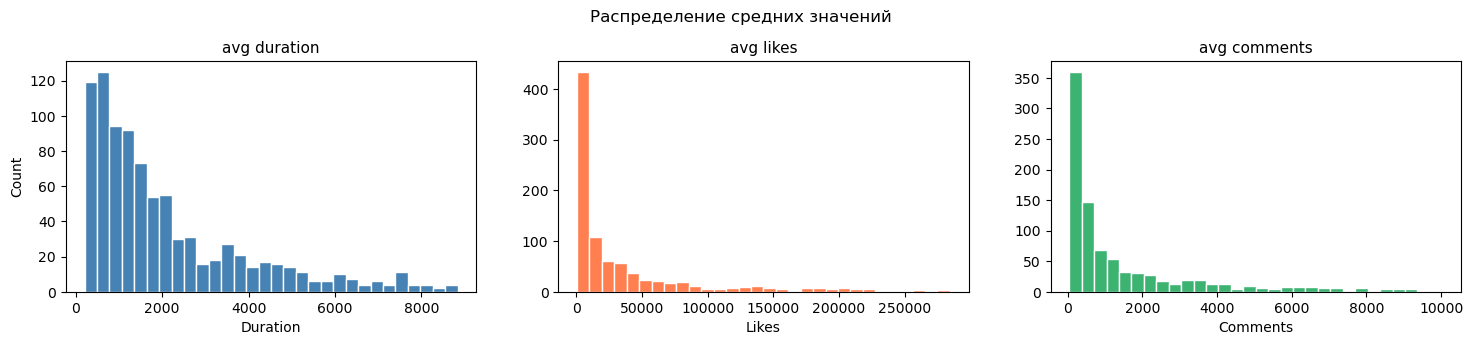

In [173]:
metrics = ["duration", "likes", "comments"]
colors = ["steelblue", "coral", "mediumseagreen"]

fig, axes = plt.subplots(1, 3, figsize=(18, 3))

for i, metric in enumerate(metrics):
    col = f"avg_{metric}"
    data = y_data[col].dropna()
    
    #выбросы
    data = data[(data >= data.quantile(0.05)) & (data <= data.quantile(0.95))]
    
    axes[i].hist(data, bins=30, color=colors[i], edgecolor="white")
    axes[i].set_title(f"avg {metric}", fontsize=11)
    axes[i].set_xlabel(metric.capitalize())
    axes[i].set_ylabel("Count" if i == 0 else "")

plt.suptitle("Распределение средних значений", y=1.05)
plt.show()

По длительности большинство видео укладывается в диапазон 500–1500 секунд, что соответствует стандартным игровым обзорам и летсплеям длиной 8–25 минут, однако хвост распределения тянется до 8000+ секунд за счёт длинных стримов и лонгплеев. По лайкам основная масса игр набирает до 25 тысяч в среднем, и лишь единицы вырываются за 150 тысяч - это крупные тайтлы с вирусным контентом. Комментарии ведут себя схожим образом, но хвост короче: большинство игр получают до 1000 комментариев, поскольку аудитория лайкает значительно активнее, чем пишет

Значения просмотров исчисляются в милионах, поэтому посмотрим отдельно на их распределение

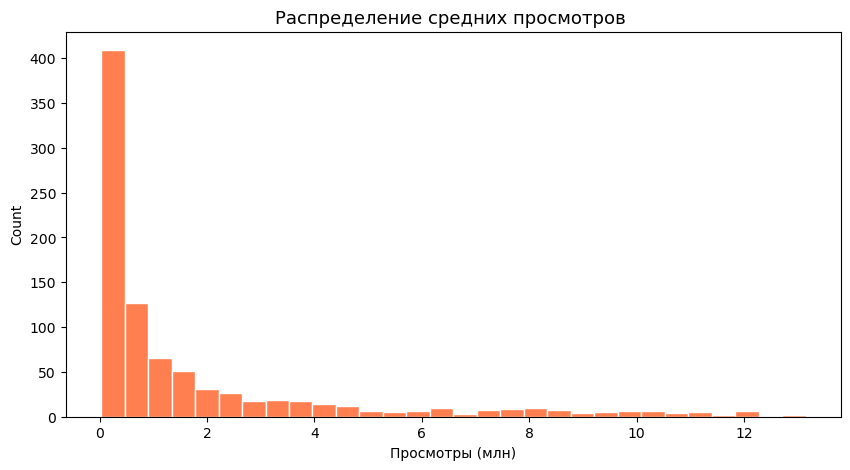

In [174]:
fig, ax = plt.subplots(figsize=(10, 5))

data = y_data["avg_views"].dropna()
data = data[(data >= data.quantile(0.05)) & (data <= data.quantile(0.95))]

#масштаб
data_m = data / 1000000

ax.hist(data_m, bins=30, color="coral", edgecolor="white")
ax.set_title("Распределение средних просмотров ", fontsize=13)
ax.set_xlabel("Просмотры (млн)")
ax.set_ylabel("Count")

plt.show()

Подавляющее большинство игр набирает менее 500 тысяч просмотров в среднем по пяти видео, а пик приходится на диапазон до 250 тысяч

топ 10 популярных каналов

In [175]:
y_channels = y_data.melt(
    value_vars=["yt_video_1_channel","yt_video_2_channel","yt_video_3_channel","yt_video_4_channel","yt_video_5_channel"],
    value_name="channel").dropna()
y_channels["channel"].value_counts().head(10)


channel
IGN                    156
PlayStation            155
Nintendo of America    131
Markiplier             123
jacksepticeye           82
The Escapist            47
Aliensrock              42
Splattercatgaming       39
Blitz                   36
Northernlion            36
Name: count, dtype: int64

С точки зрения бизнеса топ каналов показывает, кто  формирует восприятие игр у аудитории: IGN и PlayStation лидируют с большим отрывом, Markiplier и jacksepticeye представляют инфлюенсер-сегмент

Проанализируем длительность для понимания типа контента и переведем время в минуты

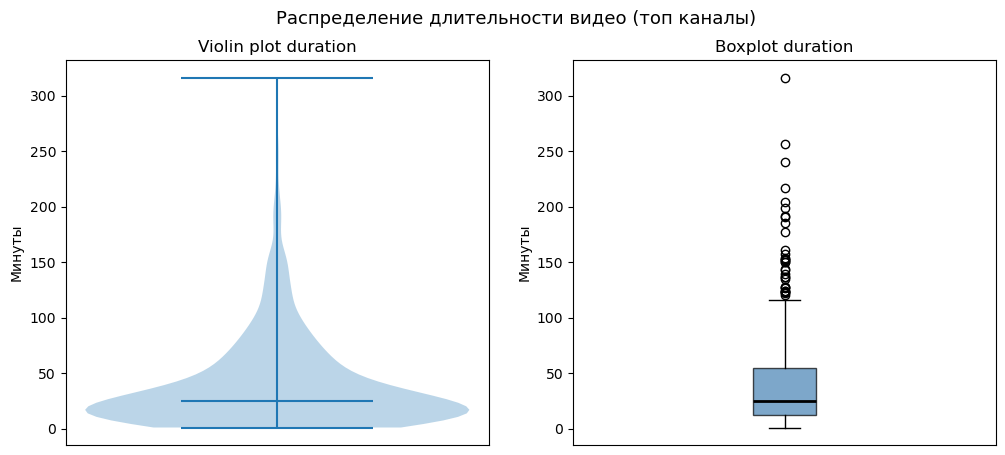

In [176]:
top_channels = ["IGN", "PlayStation", "Nintendo of America", "Markiplier", "jacksepticeye",
                "The Escapist", "Aliensrock", "Splattercatgaming", "Blitz", "Northernlion"]

channel_cols = [f"yt_video_{i}_channel" for i in range(1, 6)]
mask = y_data[channel_cols].isin(top_channels).any(axis=1)
data = y_data.loc[mask, "avg_duration"].dropna() / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].violinplot(data, showmedians=True)
axes[0].set_title("Violin plot duration", fontsize=12)
axes[0].set_ylabel("Минуты")
axes[0].set_xticks([])

axes[1].boxplot(data, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7),
                medianprops=dict(color="black", linewidth=2))
axes[1].set_title("Boxplot duration", fontsize=12)
axes[1].set_ylabel("Минуты")
axes[1].set_xticks([])

plt.suptitle("Распределение длительности видео (топ каналы)", fontsize=13)
plt.show()

медиана длительности видео у топ-каналов составляет около 25 минут, а 50% видео укладываются в диапазон примерно от 5 до 55 минут — это стандартный летсплей или обзор

violin plot наглядно демонстрирует, что основная масса контента сконцентрирована в нижней части распределения, ближе к коротким видео

Рассмотрим активность пользователей и возмем по этому показателю также топ 10

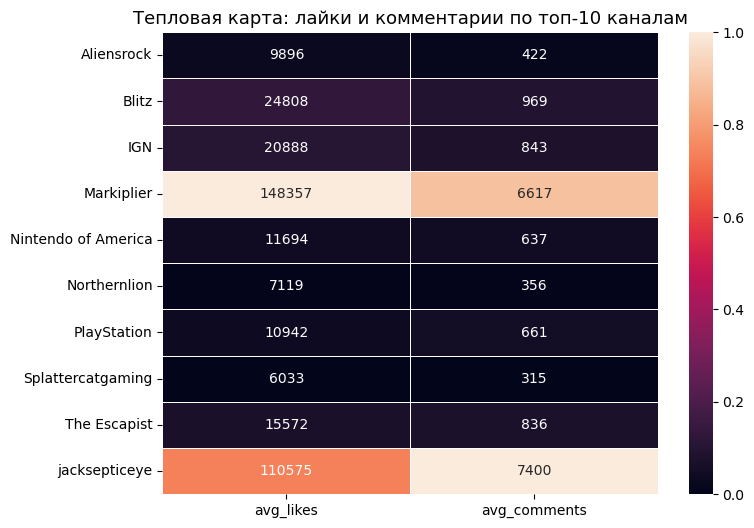

In [177]:
rows = []
for i in range(1, 6):
    temp = y_data[["avg_likes", "avg_comments", f"yt_video_{i}_channel"]].copy()
    temp.columns = ["avg_likes", "avg_comments", "channel"]
    rows.append(temp)

long_df = pd.concat(rows).dropna(subset=["channel"])

top10 = long_df["channel"].value_counts().head(10).index
df_top = long_df[long_df["channel"].isin(top10)]

heatmap_data = df_top.groupby("channel")[["avg_likes", "avg_comments"]].mean().astype(float)

#нормализуем для читаемости
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(0), fmt=".0f", linewidths=0.5, ax=ax)
ax.set_title("Тепловая карта: лайки и комментарии по топ-10 каналам", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

Тепловая карта разделяет каналы на два сегмента Jacksepticeye и Markiplier резко выделяются на фоне остальных — 110 тысяч и 148 тысяч лайков соответственно, и при этом самые высокие комментарии: 7400 и 6600. Это инфлюенсеры с глубоко вовлечённой аудиторией, которая активно реагирует на контент.
Все остальные каналы — IGN, PlayStation, Nintendo of America, The Escapist показывают на порядок меньше лайков и комментариев. Это говорит о том, что медиа и официальные издатели генерируют охват, но не вовлечённость — люди смотрят обзоры с меньшим желанием взаимодействовать

присутствие видео от инфлюенсеров может быть более сильной фичей для предсказания популярности игры, чем покрытие от крупных медиа